                                                                        Predicting Passenger Survival on the Titanic Using Machine Learning                   
Business Problem : 
The sinking of the Titanic remains one of history's most well-known maritime disasters. Although there was an element of chance, survival was influenced by several factors such as passenger class, age, gender, family size, and fare paid.
The goal of this project is to build a machine learning model that predicts whether a passenger survived based on available passenger information.

Problem Statement : Can we accurately predict whether a passenger survived the Titanic disaster using demographic and travel-related characteristics?

Project Objectives

1. Clean and prepare the Titanic dataset

2. Handle missing values

3. Convert categorical variables into numerical features

4. Scale numerical features

5. Split the data into training and testing datasets

6. Train multiple classification models

7. Compare model performance

8. Identify the most important factors affecting survival


Dataset

Typical features include:

Feature	:        Description

PassengerId :	    Passenger identifier

Survived	:     Target variable (0 = No, 1 = Yes)

Pclass	 :       Passenger class


Sex	       :     Male/Female

Age	       :     Passenger age

SibSp	   :     Number of siblings/spouses aboard

Parch	    :    Number of parents/children aboard

Ticket	    :    Ticket number

Fare	   :     Ticket fare

Cabin	   :     Cabin number

Embarked	:    Port of embarkation

Step 1: Import Libraries

In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


Step 2 : Load Dataset

In [3]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Step 3: Data Exploration (EDA)

Exploring the dataset by answering questions such as:

How many passengers survived?
Does gender affect survival?
Did first-class passengers survive more often?
What age groups had the highest survival rates?
Does fare correlate with survival?
Which embarkation port had the highest survival rate?

In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Survival Count

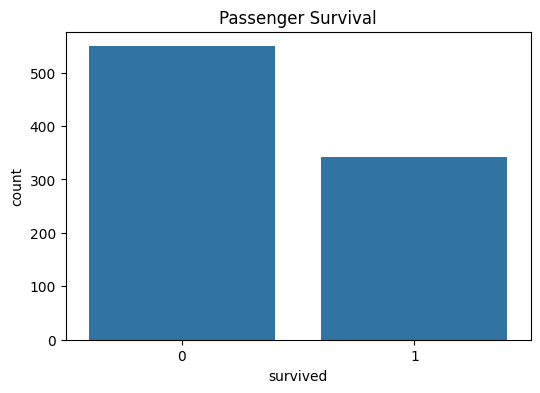

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='survived')
plt.title("Passenger Survival")
plt.show()

Survival by Gender

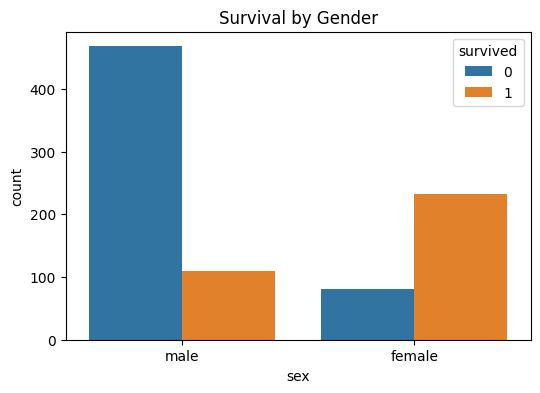

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sex', hue='survived')
plt.title("Survival by Gender")
plt.show()

Survival by Passenger Class

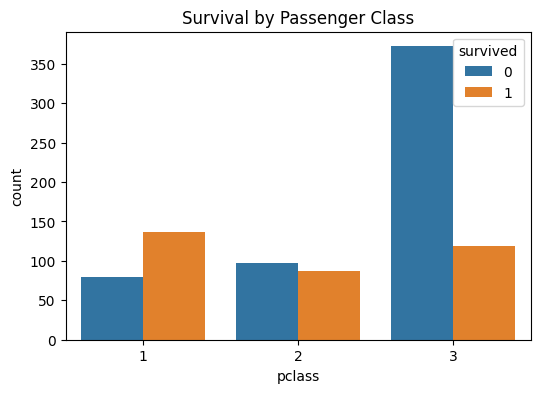

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='pclass', hue='survived')
plt.title("Survival by Passenger Class")
plt.show()

Age Distribution

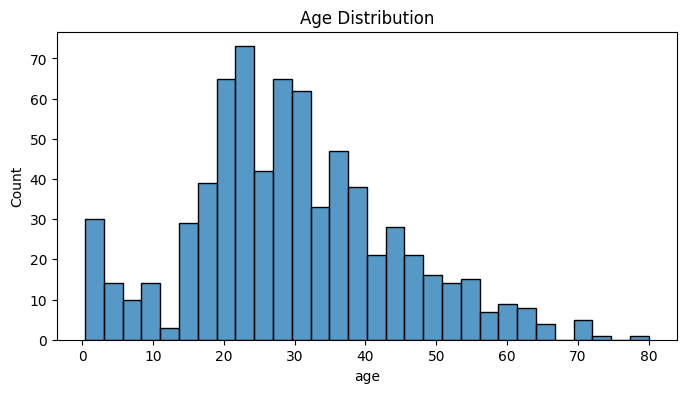

In [8]:
plt.figure(figsize=(8,4))
sns.histplot(df['age'], bins=30)
plt.title("Age Distribution")
plt.show()

Fare Distribution

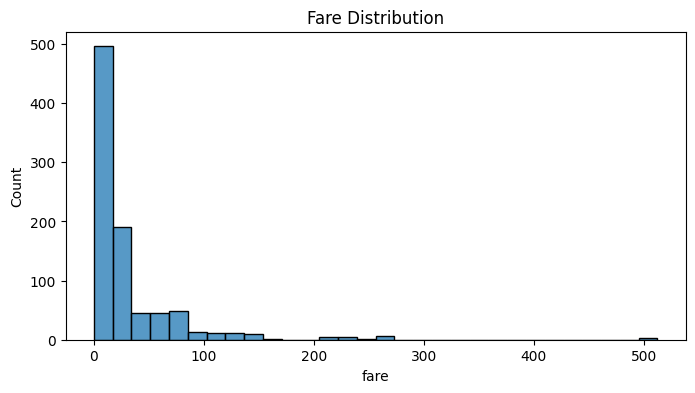

In [9]:
plt.figure(figsize=(8,4))
sns.histplot(df['fare'], bins=30)
plt.title("Fare Distribution")
plt.show()

Correlation Heatmap

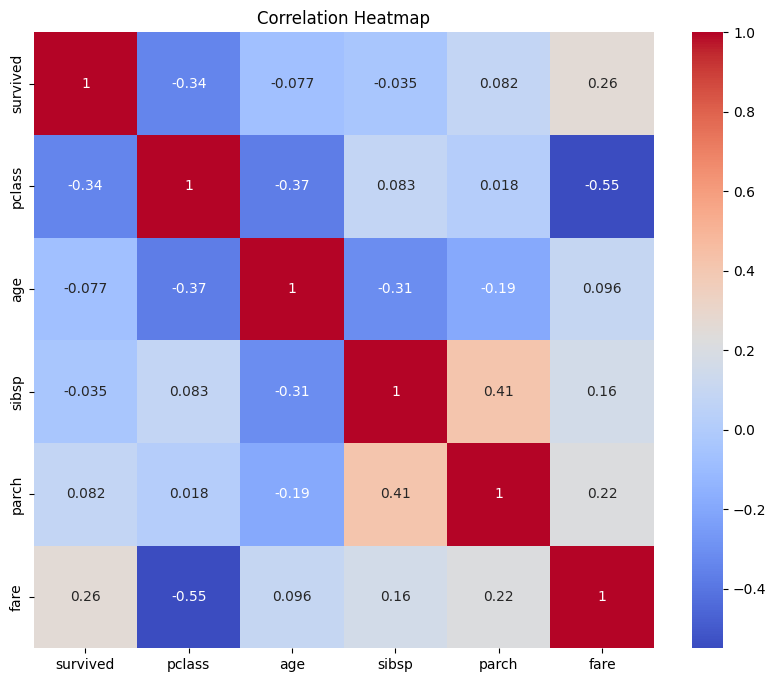

In [10]:
numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(numeric.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Step 4: Data Cleaning

In [11]:
##Fill Missing Age Values with Median
df['age'].fillna(df['age'].median(), inplace=True)

C:\Users\VBACOMishrR\AppData\Local\Temp\1\ipykernel_30108\1449144932.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)


In [ ]:
##Fill Missing Embarked Values with Mode
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

C:\Users\VBACOMishrR\AppData\Local\Temp\1\ipykernel_6128\448661275.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)


Step 5: Feature Engineering

In [12]:
##Family Size
df['family_size'] = df['sibsp'] + df['parch'] + 1

In [13]:
##Travelling Alone
df['is_alone'] = (df['family_size'] == 1).astype(int)

Step 7: Create Dummy Variables

In [22]:
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)

Step 8: Standardize Numeric Features

In [25]:
scaler = StandardScaler()

numeric_features = [
    'age',
    'fare',
    'sibsp',
    'parch',
    'family_size'
]

df[numeric_features] = scaler.fit_transform(df[numeric_features])

Step 9: Split Features and Target

In [28]:
X = df.drop('survived', axis=1)

y = df['survived']

Step 10 : Train/Test Split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(668, 17)
(223, 17)


In [32]:
df = pd.get_dummies(df, drop_first=True)

In [34]:
X = df.drop("survived", axis=1)
y = df["survived"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

Step 11 : Train Logistic Regression

In [35]:
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

Step 12 : Train Decision Tree

In [36]:
tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)

Step 13: Train Random Forest

In [37]:
forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

forest.fit(X_train, y_train)

forest_pred = forest.predict(X_test)

Step 14 : Train KNN

In [38]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

Step 15: Train Support Vector Machine

In [39]:
svm = SVC()

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

Step 16: Compare Accuracy

In [40]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "Support Vector Machine"
    ],
    "Accuracy":[
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, forest_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, svm_pred)
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
0,Logistic Regression,1.000000
1,Decision Tree,1.000000
2,Random Forest,1.000000
4,Support Vector Machine,0.995516
3,KNN,0.937220


Step 17: Classification Report (Random Forest)

In [41]:
print(classification_report(y_test, forest_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       134
           1       1.00      1.00      1.00        89

    accuracy                           1.00       223
   macro avg       1.00      1.00      1.00       223
weighted avg       1.00      1.00      1.00       223



Step 18: Confusion Matrix

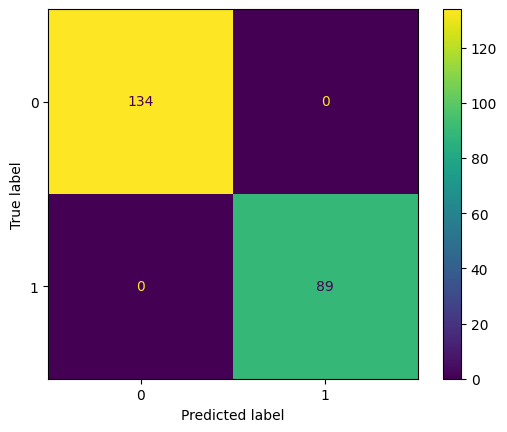

In [42]:
cm = confusion_matrix(y_test, forest_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.show()

Step 19 : Feature Importance

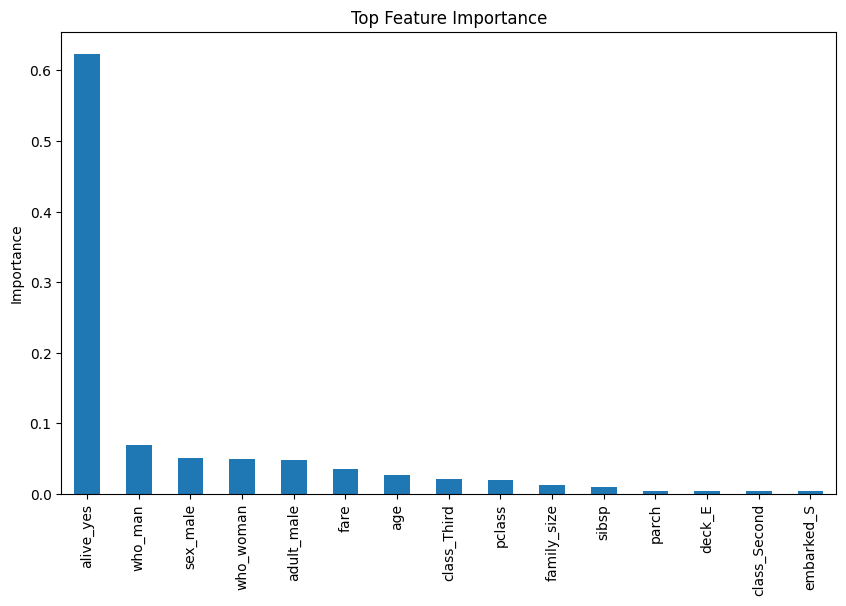

In [43]:
importance = pd.Series(
    forest.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

##Top 15 Features
plt.figure(figsize=(10,6))

importance.head(15).plot(kind='bar')

plt.title("Top Feature Importance")

plt.ylabel("Importance")

plt.show()

Step 20: Compare All Models Visually

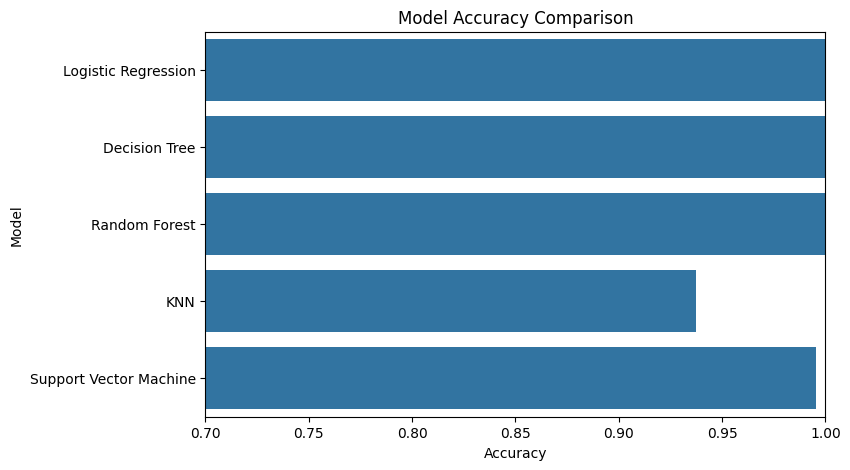

In [44]:
plt.figure(figsize=(8,5))

sns.barplot(data=results, x='Accuracy', y='Model')

plt.xlim(0.7,1)

plt.title("Model Accuracy Comparison")

plt.show()

Step 21: Make a Prediction for a New Passenger

In [45]:
sample_passenger = X.iloc[[0]]

prediction = forest.predict(sample_passenger)

if prediction[0] == 1:
    print("Passenger would likely SURVIVE")
else:
    print("Passenger would likely NOT survive")

Passenger would likely NOT survive


Step 22: Conclusions

In [46]:
print("Highest Accuracy Model:")
print(results.sort_values(by='Accuracy', ascending=False).head(1))

Highest Accuracy Model:
                 Model  Accuracy
0  Logistic Regression       1.0


After preprocessing the Titanic dataset and training several classification models, the Random Forest classifier achieved the highest predictive performance. The analysis showed that gender, passenger class, fare paid, age, and family size were among the strongest predictors of survival. This project demonstrates how data preprocessing—including handling missing values, encoding categorical variables, scaling numerical features, and engineering new features—can significantly improve model performance and produce actionable insights from historical data.